## DECODE processing of star-patterned data

Here we use trained DECODE model on emitters placed in a star pattern.

* Input: `input_for_cnn_star.h5`
* Output: `decode_output_star.h5`

The output is then processed `generate_figure.ipynb`.


In [170]:
import sys
import decode
import decode.utils
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml
import h5py
import scipy.ndimage as ndi

def l1norm(a):
    """
    L1 norm.
    """
    asu = a - np.min(a)
    norm = np.sum(asu)
    if norm == 0:
        return np.zeros_like(a)
    return asu/norm

def upscale_and_round_to_grid(x, y):
    kappa = 1
    xnear = int(np.round(x*4*kappa)+1.5) + 1 #these values are here to compensate systematic shift of the DECODE
    ynear = int(np.round(y*4*kappa)+1.5) + 1
    return ynear, xnear    
    
def generate_decode_image(decode_xyi, h, w, shift_foo):    
    """
    Generates a 2D image from a storm table by mapping localizations to pixel coordinates.

    Parameters:
        decode_xyi ... TODO
        h (int): Height of the output image in pixels.
        w (int): Width of the output image in pixels.

    Returns:
        numpy.ndarray: A 2D array of shape (h, w) representing the generated image, where each 
                       pixel value corresponds to the summed intensity and offset of localizations 
                       mapped to that pixel.

    Notes:
        - The function assumes a fixed scaling factor (kappa = 1/60 nm/px) to convert 
          nanometer coordinates to pixel coordinates.
        - It works with fixed upscaling factor 4x
        - Localizations are rounded to the nearest pixel using nearest-neighbor rounding.
        - If a localization falls outside the image bounds, it is ignored.
        - If multiple localizations map to the same pixel, their intensities and offsets are summed.
        - A warning message is printed if a pixel is overwritten by multiple localizations.
    """
    #"id","frame","x [nm]","y [nm]","sigma [nm]","intensity [photon]","offset [photon]","bkgstd [photon]","chi2","uncertainty [nm]"
    img = np.zeros((h,w), dtype=np.float64)
    # kappa = 1#1/60 #nm/px of object space
    #read storm table
    for x, y, intensity in decode_xyi:
        #fixed upscale factor 4 here, factor 1.5 is due to grid fitting
        xnear, ynear = shift_foo(x, y)
        if (xnear >= w) or (xnear < 0) or (ynear >= h) or (ynear < 0):
            continue
        if img[ynear, xnear] != 0:
            print("Ooops!", xnear, ynear, 'is already there')
        img[ynear, xnear] += (intensity)
    return img
    
print(f"DECODE version: {decode.utils.bookkeeping.decode_state()}")

DECODE version: 0.10.2


In [171]:
#Setup

INPUT = 'input_for_cnn_star.h5'
OUTPUT = 'decode_output_star.h5'

device = 'cuda:0'  # or 'cpu', or you change cuda device index
threads = 4  #  number of threads, useful for CPU heavy computation. Change if you know what you are doing.
worker = 0  # number of workers for data loading. Used a default of 0 for safety. Multiprocessing on windows is sometimes not stable

torch.set_num_threads(threads)  # set num threads

if device != 'cpu':
    if not torch.cuda.is_available():
        raise ValueError("You have selected a non CPU device, but CUDA is not available."
                         "Refer to CPU version or check your installation.")

# here you need to specify the parameters with suffix _run.yaml in your model's output folder (not param_run_in.yaml)
param_path = '../decode-model/gaussian_psf_2px/param_run.yaml'
model_path = '../decode-model/gaussian_psf_2px/model_0.pt'

# specify camera parameters of tiffs, these are synthetic data, so turn off photon conversion
# the specs are the same as in the training (up to SNR)
meta = {
    'Camera': {
        'baseline': 50,
        'e_per_adu': 1.0,
        'em_gain': 1.0,
        'spur_noise': 0.000,  # if you don't know, you can set this to 0.
        'convert_photons' : False,
        'px_size': (60,60)
    }
}

param = decode.utils.param_io.load_params(param_path)
model = decode.neuralfitter.models.SigmaMUNet.parse(param)
model = decode.utils.model_io.LoadSaveModel(model,
                                            input_file=model_path,
                                            output_file=None).load_init(device=device)
# overwrite camera
param = decode.utils.param_io.autofill_dict(meta['Camera'], param.to_dict(), mode_missing='include')
param = decode.utils.param_io.RecursiveNamespace(**param)

Model instantiated.
Model SHA-1 hash: f970a8ee6ad917eaa0c05db6f812d2528ca2066c
Loaded pretrained model: ../decode-model/gaussian_psf_2px/model_0.pt


In [172]:
#setup DECODE pipeline
#this is a modified chunk of the original DECODE tutorial notebook

# setup frame processing as by the parameter with which the model was trained
frame_proc = decode.neuralfitter.utils.processing.TransformSequence([
    # decode.neuralfitter.utils.processing.wrap_callable(camera.backward), #no conversion from photon to ADU
    decode.neuralfitter.frame_processing.AutoCenterCrop(8),
    #decode.neuralfitter.frame_processing.Mirror2D(dims=-1),  # no mirroring
    decode.neuralfitter.scale_transform.AmplitudeRescale.parse(param) #keep rescaling
])

# determine extent of frame and its dimension after frame_processing
frames = torch.rand((10,50,50))
size_procced = decode.neuralfitter.frame_processing.get_frame_extent(frames.unsqueeze(1).size(), frame_proc.forward)  # frame size after processing
frame_extent = ((-0.5, size_procced[-2] - 0.5), (-0.5, size_procced[-1] - 0.5))

# Setup post-processing
# It's a sequence of backscaling, relative to abs. coord conversion and frame2emitter conversion
post_proc = decode.neuralfitter.utils.processing.TransformSequence([
    decode.neuralfitter.scale_transform.InverseParamListRescale.parse(param),
    decode.neuralfitter.coord_transform.Offset2Coordinate(xextent=frame_extent[0],
                                                          yextent=frame_extent[1],
                                                          img_shape=size_procced[-2:]),

    decode.neuralfitter.post_processing.SpatialIntegration(raw_th=0.1,
                                                          xy_unit='px',
                                                          px_size=param.Camera.px_size)
])

In [173]:
#instantiate predictor object
infer = decode.neuralfitter.Infer(model=model, ch_in=param.HyperParameter.channels_in,
                                  frame_proc=frame_proc, post_proc=post_proc,
                                  device=device, num_workers=worker)

def em_to_xyi(em_obj):
    xyz = em_obj.xyz
    phot = em_obj.phot
    print(len(xyz), 'em')
    xyi = np.zeros((xyz.shape[0], 3))
    xyi[:,0:2] = xyz[:,0:2]
    xyi[:,2] = phot
    xyi[:,0] += 0.5
    xyi[:,1] += 0.5
    return xyi

emitters_xyi = []
with h5py.File(INPUT, 'r') as h5fi, h5py.File(OUTPUT, 'w') as h5fo:
    for dsetkey, dset in h5fi.items():
        print(dsetkey)
        #this multiplication is for some reason important for decode
        frames = torch.from_numpy((np.array(dset)*1e6).astype(np.int32))
        _frames = [(frames[i:(i+1)].reshape((1,50,50))) for i in range(frames.shape[0])]
        emitters = [em_to_xyi(infer.forward(_f)) for _f in _frames]
        emitters_xyi.append(emitters)
        
        transformed_stack = [generate_decode_image(xyi, 200, 200, upscale_and_round_to_grid) for xyi in emitters]        
        h5fo.create_dataset(dsetkey, data=np.array(transformed_stack))
        
        

star_vs_snr


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 106.45it/s]


3 em


100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 95.72it/s]


2 em


...

13 em


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 109.21it/s]


13 em


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 111.13it/s]

13 em


In [174]:
with h5py.File(INPUT, 'r') as h5fi:
    print(h5fi['star_vs_snr'])
    img = np.array(h5fi['star_vs_snr'][-1])

<HDF5 dataset "star_vs_snr": shape (110, 50, 50), type "<f4">


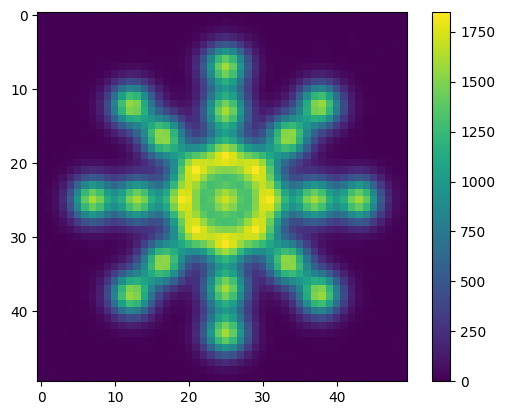

In [175]:
plt.imshow(img*1_000_000)
plt.colorbar()
plt.show()

In [176]:
imgt = torch.from_numpy((1_000_000*img.reshape((1,50,50))).astype(np.int32))

In [177]:
emset = infer.forward(imgt)

100%|█████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 17.52it/s]


13 em


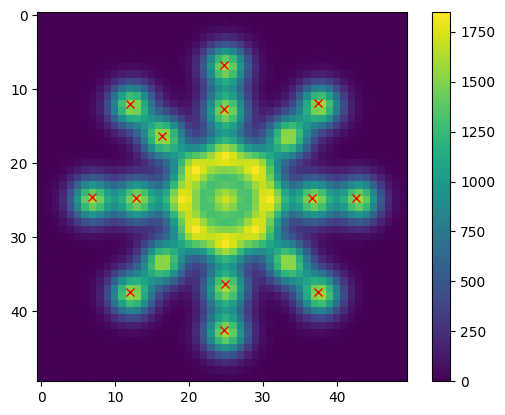

In [178]:
plt.imshow(img*1_000_000)
xyi = em_to_xyi(emset)
plt.plot(xyi[:,0],xyi[:,1], "rx")
plt.colorbar()
plt.show()

['star_vs_snr']


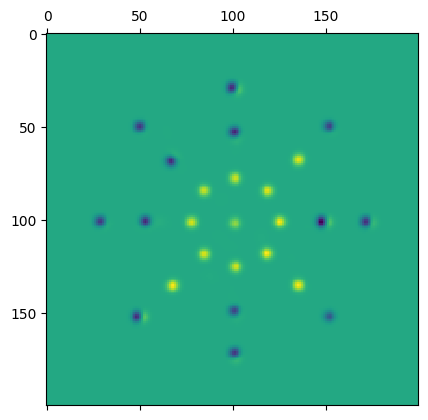

In [179]:
with h5py.File('cnn_output_star.h5', 'r') as h5:
    print(list(h5.keys()))
    imr = np.array(h5['star_vs_snr'])[-1,:,:,0]

# def upscale_and_round_to_grid(x, y):
#     kappa = 1
#     xnear = int(np.round(x*4*kappa)+1.5) + 0*1 #these values are here to compensate systematic shift of the DECODE
#     ynear = int(np.round(y*4*kappa)+1.5) + 0*1
#     return xnear, ynear

def upscale_and_round_to_grid(x, y):
    kappa = 1
    xnear = int(np.round(x*4*kappa)+1.5) + 1 #these values are here to compensate systematic shift of the DECODE
    ynear = int(np.round(y*4*kappa)+1.5) + 1
    return ynear, xnear    
    
im2 = generate_decode_image(emitters_xyi[0][-1], 200, 200, upscale_and_round_to_grid)
r1 = l1norm(ndi.gaussian_filter(im2,2))
r2 = l1norm(ndi.gaussian_filter(imr,2))
plt.matshow(r2-r1)
plt.show()